**COMPETICAO ML PARA PREDICAO DE VINHOS - NEURON**
# Requisitos de Instalação
- Basta rodar o arquivo `install.bat` no cmd ou terminal, ele já contem todas as dependencias utilizadas no projeto

# Dependências Utilizadas
* Conforme requisitado no MarkDown de Explicação do projeto, as dependências utilizadas são:
* Pandas (Tratamento de dados e arquivos)
* Numpy (Funções matemáticas)
* Matplotlib (Vizualização de dados)
* Seaborn (Vizualização de dados)
* Scikit-learn (Machine Learning) #tive que substituir o sklearn por scikit-learn 



Parte 1) Importação 


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Parte 2) Leitura e Analise de Dados do `Train.csv`

In [83]:
train = pd.read_csv("train.csv",na_values = '-', index_col= 0) #Usa a coluna Id do CSV como a coluna Id do Data Structure do Pandas
matriz_treinamento = train.values
train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
id,,,,,,,,,,,,
0,9.3,0.40,0.34,2.1,0.088,14.0,28.0,0.99940,3.44,0.84,12.2,7.0
1,8.3,0.38,0.33,1.8,0.070,5.0,15.0,0.99820,3.39,0.55,9.9,5.0
2,6.6,0.28,0.30,2.1,0.068,8.0,17.0,0.99552,3.51,0.80,10.7,6.0
3,8.2,0.35,0.36,2.6,0.086,14.0,89.0,0.99910,3.23,0.67,9.5,5.0
4,10.9,0.18,0.49,1.8,0.084,21.0,77.0,0.99658,3.20,0.63,9.5,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,8.2,0.30,0.49,3.0,0.075,8.0,21.0,0.99656,3.47,0.52,9.8,5.0
14996,7.3,0.50,0.00,2.1,0.084,24.0,42.0,0.99562,3.39,0.56,12.6,7.0
14997,8.0,0.56,0.12,2.2,0.071,23.0,40.0,0.99702,3.19,0.60,9.8,6.0


In [84]:
print("Shape:", train.shape)

Shape: (15000, 12)


In [85]:
print("\nTipos de dados:\n", train.dtypes)


Tipos de dados:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                 float64
dtype: object


In [86]:
print("\nValores nulos por coluna:\n", train.isnull().sum())
print("\nExistem nulos no dataframe?:", train.isnull().any().any())


Valores nulos por coluna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Existem nulos no dataframe?: False


In [87]:
print("\nEstatísticas descritivas:\n", train.describe().T)


Estatísticas descritivas:
                         count       mean        std      min      25%  \
fixed acidity         15000.0   8.141927   1.381534  4.60000   7.2000   
volatile acidity      15000.0   0.505266   0.134270  0.12000   0.4000   
citric acid           15000.0   0.231299   0.176764  0.00000   0.0500   
residual sugar        15000.0   2.189266   0.505553  1.10000   1.9000   
chlorides             15000.0   0.078641   0.013768  0.01200   0.0730   
free sulfur dioxide   15000.0  13.234033   7.916878  1.00000   6.0000   
total sulfur dioxide  15000.0  37.178500  24.034172  5.00000  20.0000   
density               15000.0   0.996915   0.001399  0.99064   0.9959   
pH                    15000.0   3.320703   0.115140  2.88000   3.2400   
sulphates             15000.0   0.618600   0.105734  0.39000   0.5500   
alcohol               15000.0  10.187160   0.912091  6.40000   9.5000   
quality               15000.0   5.660600   0.804892  3.00000   5.0000   

                      

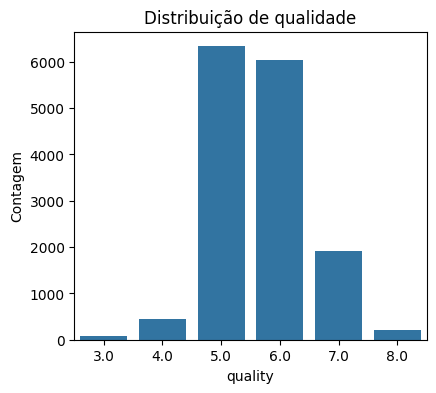

In [88]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x='quality', data=train, stat = 'count')
plt.title('Distribuição de qualidade')
plt.xlabel('quality')
plt.ylabel('Contagem')
plt.show()

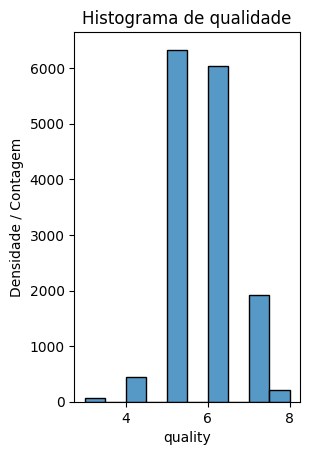

In [89]:
plt.subplot(1,2,2)
sns.histplot(train['quality'], bins=10)
plt.title('Histograma de qualidade')
plt.xlabel('quality')
plt.ylabel('Densidade / Contagem')
plt.show()
# histograma coluna qualidade

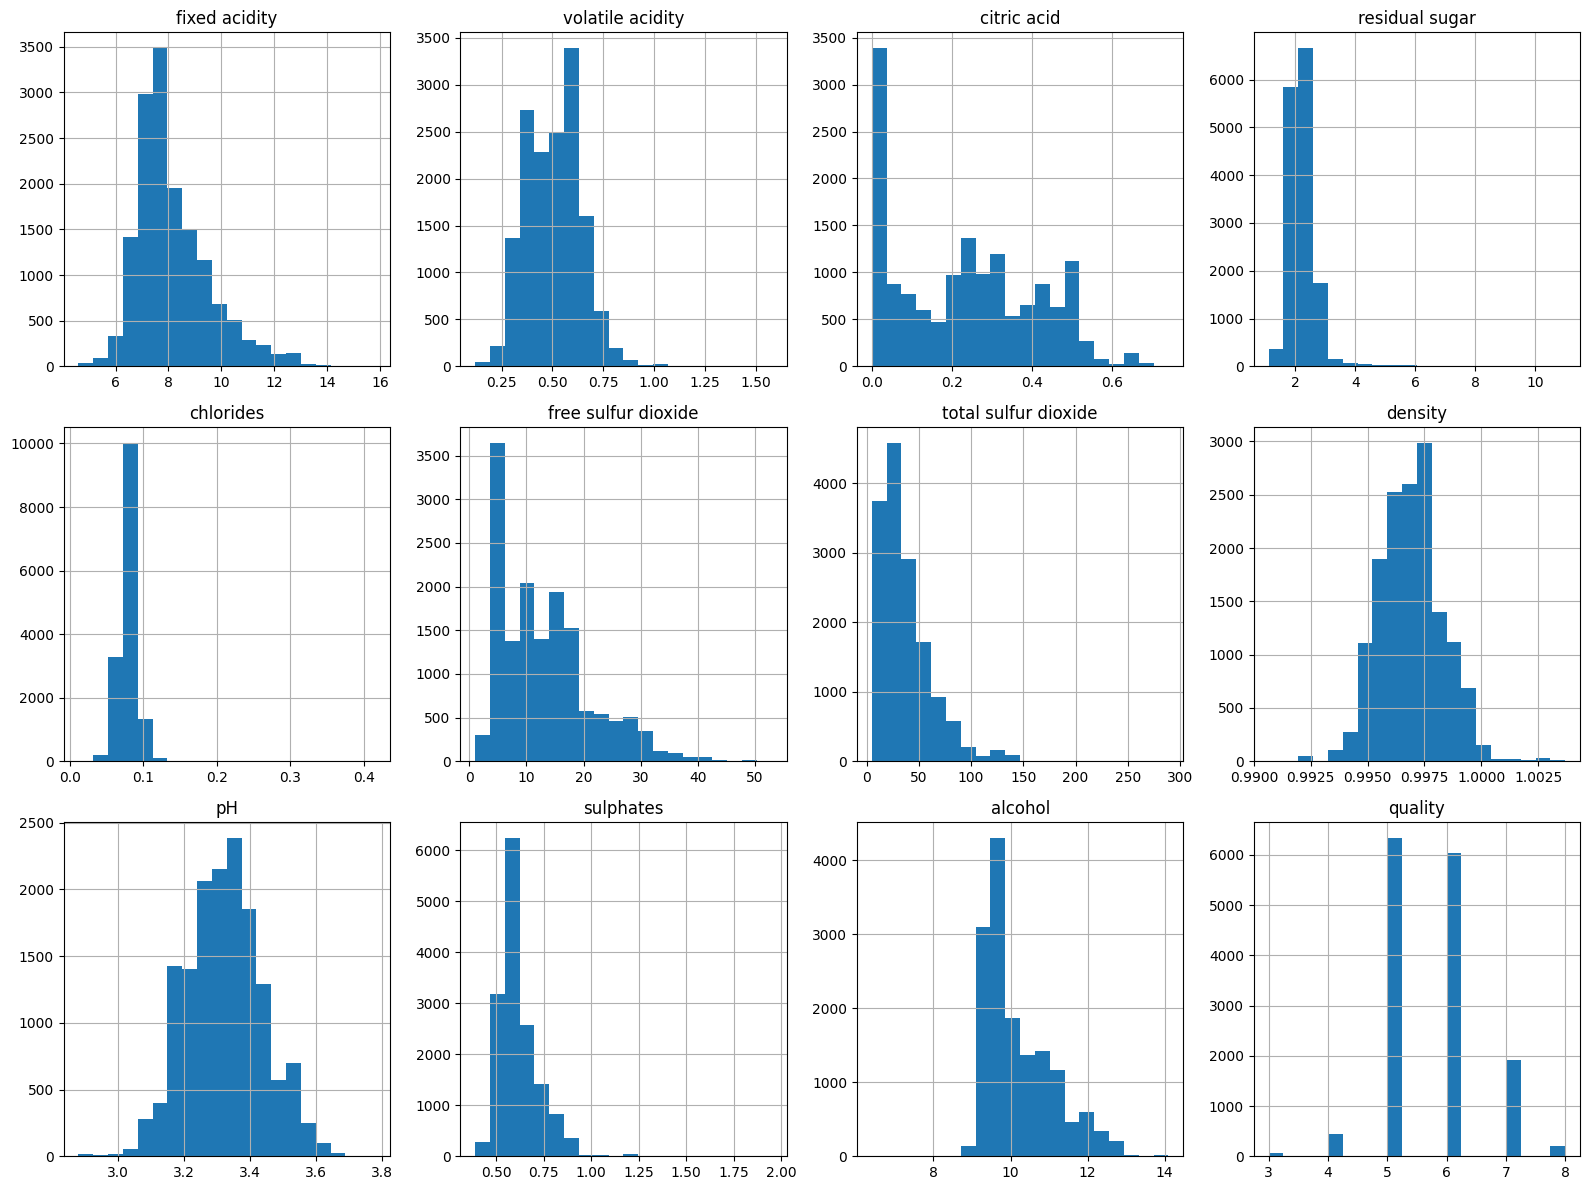

In [90]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
train[num_cols].hist(bins=20, figsize=(16,12), layout=(int(np.ceil(len(num_cols)/4)),4))
plt.tight_layout()
plt.show() # histograma de todas as colunas

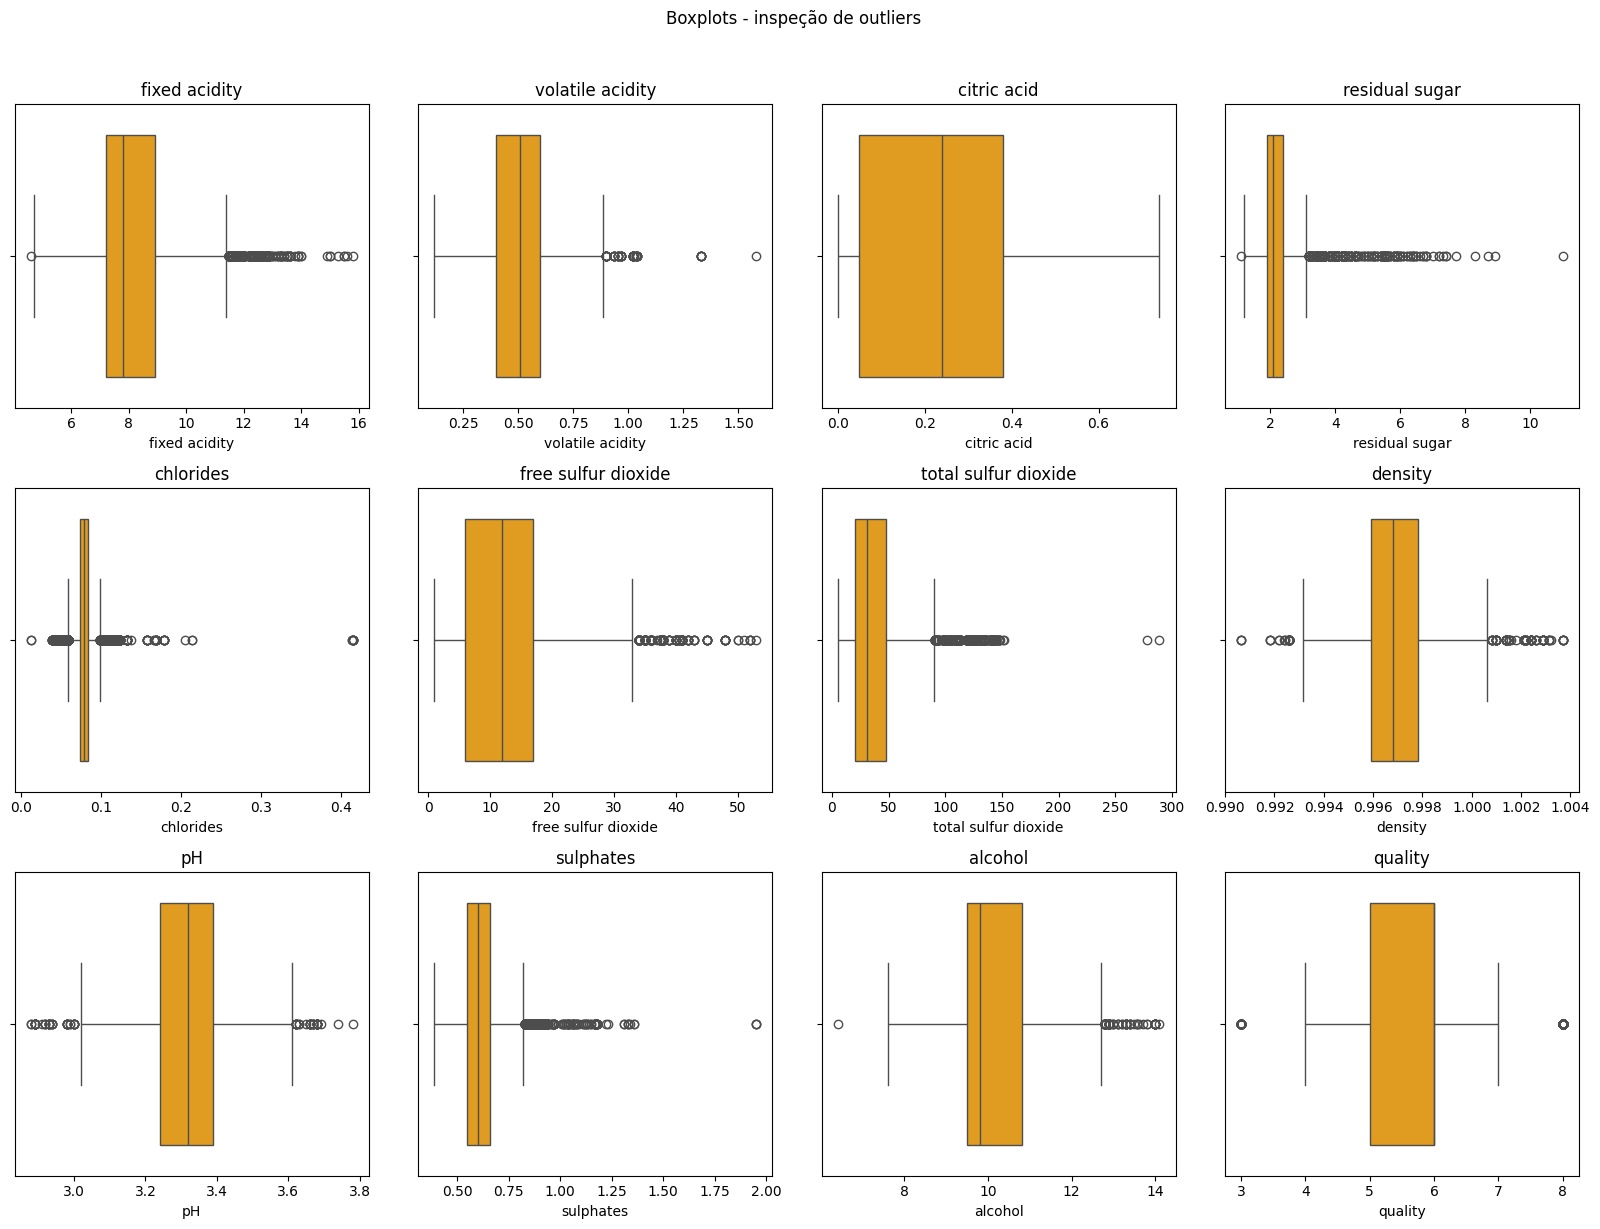

In [91]:
#Boxplots para checar outliers por coluna
plt.figure(figsize=(16,12))
cols_per_row = 4
rows = int(np.ceil(len(num_cols)/cols_per_row))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=train[col], color='orange')
    plt.title(col)
plt.suptitle('Boxplots - inspeção de outliers', y=1.02)
plt.tight_layout()
plt.show()

In [92]:
iso_forest = IsolationForest(contamination=0.2, random_state=42)
outlier_predictions = iso_forest.fit_predict(train)
train = train[outlier_predictions == 1] 

#Remoção de outliers

In [93]:
corr = train.corr()
corr # matriz de correlação entre colunas

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.296294,0.560044,0.041715,0.041040,-0.090268,-0.048116,0.161380,-0.368344,0.132283,-0.023512,-0.009701
volatile acidity,-0.296294,1.000000,-0.649510,-0.045086,-0.045546,-0.007609,-0.028037,-0.058297,0.215353,-0.162311,-0.028911,0.007783
citric acid,0.560044,-0.649510,1.000000,0.064834,0.063965,-0.008266,0.024209,0.137428,-0.396765,0.202818,0.018981,-0.009789
residual sugar,0.041715,-0.045086,0.064834,1.000000,0.037759,0.001302,0.011957,0.019552,-0.027934,0.007103,0.051348,0.011905
chlorides,0.041040,-0.045546,0.063965,0.037759,1.000000,0.017109,0.028227,0.045394,-0.032082,0.010540,-0.047913,-0.006268
free sulfur dioxide,-0.090268,-0.007609,-0.008266,0.001302,0.017109,1.000000,0.700982,-0.015760,0.018160,-0.018687,-0.081537,-0.034965
total sulfur dioxide,-0.048116,-0.028037,0.024209,0.011957,0.028227,0.700982,1.000000,0.017123,-0.004479,-0.024847,-0.175344,-0.095410
density,0.161380,-0.058297,0.137428,0.019552,0.045394,-0.015760,0.017123,1.000000,-0.042686,0.019420,-0.106139,-0.033375
pH,-0.368344,0.215353,-0.396765,-0.027934,-0.032082,0.018160,-0.004479,-0.042686,1.000000,-0.075867,0.010046,0.018812
sulphates,0.132283,-0.162311,0.202818,0.007103,0.010540,-0.018687,-0.024847,0.019420,-0.075867,1.000000,0.057610,0.055172


<Axes: >

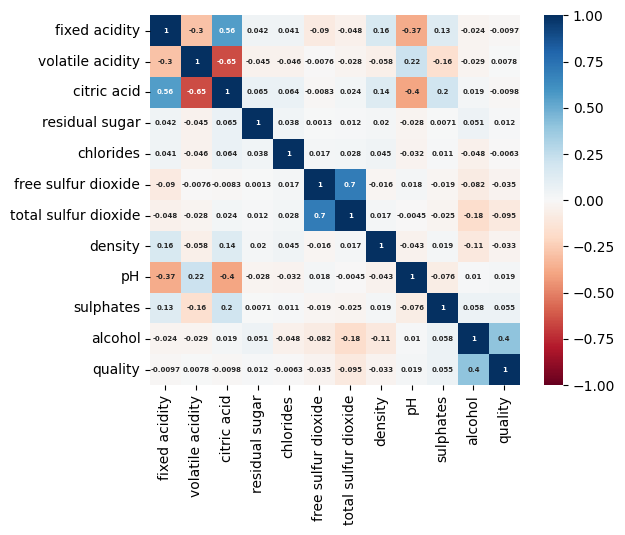

In [94]:
sns.heatmap(corr,cmap = 'RdBu', vmin = -1.0, vmax = 1.0,annot=True,square=True, annot_kws = {'fontsize' : 5, 'fontweight' : 'bold'}) 
# Função do seaborn pra criação do heatmap

In [95]:
corr_with_quality = abs(corr['quality']).sort_values(ascending=False) #ordenar por nivel de correlação com qualidade
print("Correlações com 'quality':") # correlação com o target qualidade (Y)
print(corr_with_quality)
important_features = corr_with_quality[corr_with_quality > 0.009].index.tolist() #pegar nossos candidatos pro valor de X, correlaçao > 0,05
important_features.remove('quality') #tirar qualidade dos candidatos

print("\nFeatures mais importantes:")
print(important_features) # mostrar candidatos pra analise

Correlações com 'quality':
quality                 1.000000
alcohol                 0.404455
total sulfur dioxide    0.095410
sulphates               0.055172
free sulfur dioxide     0.034965
density                 0.033375
pH                      0.018812
residual sugar          0.011905
citric acid             0.009789
fixed acidity           0.009701
volatile acidity        0.007783
chlorides               0.006268
Name: quality, dtype: float64

Features mais importantes:
['alcohol', 'total sulfur dioxide', 'sulphates', 'free sulfur dioxide', 'density', 'pH', 'residual sugar', 'citric acid', 'fixed acidity']


In [96]:
X = train[important_features] #preparar X e y
y = train['quality']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42) #80/20 e definicao de seed padrao 42 

scaler = RobustScaler() # normalizacao por StandardScaler 
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

train_results = {} #dicionarios para armazenar resultados
val_results = {}

#treinar e avaliar cada modelo
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)
    train_results[name] = {
        'R2': r2_score(y_train, y_train_pred),
        'MAE': mean_absolute_error(y_train, y_train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred))
    }                   
    val_results[name] = {
        'R2': r2_score(y_val, y_val_pred,),
        'MAE': mean_absolute_error(y_val, y_val_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_val_pred))
    }


Resultados da Avaliação dos Modelos de treino:
      Linear Regression  Random Forest  Gradient Boosting
R2               0.1681         0.8806             0.2194
MAE              0.5450         0.2026             0.5303
RMSE             0.6613         0.2506             0.6406


<Figure size 1200x600 with 0 Axes>

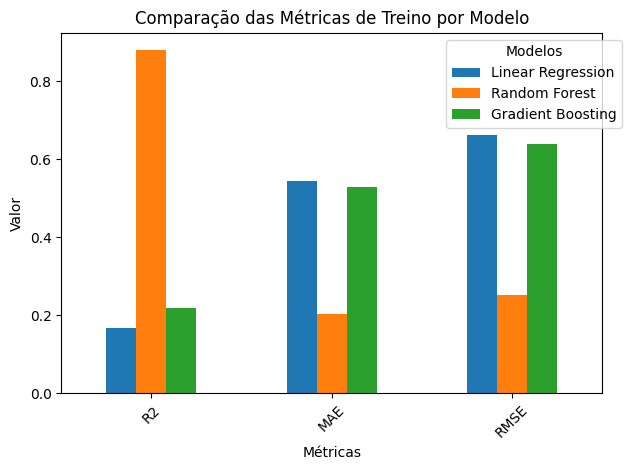

In [97]:
train_results_df = pd.DataFrame(train_results).round(4) #criar data frame pra mostrar resultados
print("\nResultados da Avaliação dos Modelos de treino:")
print(train_results_df)
plt.figure(figsize=(12, 6)) #plotar os resultados
train_results_df.plot(kind='bar')
plt.title('Comparação das Métricas de Treino por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


Resultados da Avaliação dos Modelos de validacao:
      Linear Regression  Random Forest  Gradient Boosting
R2               0.1351         0.0811             0.1400
MAE              0.5412         0.5516             0.5415
RMSE             0.6519         0.6719             0.6500


<Figure size 1200x600 with 0 Axes>

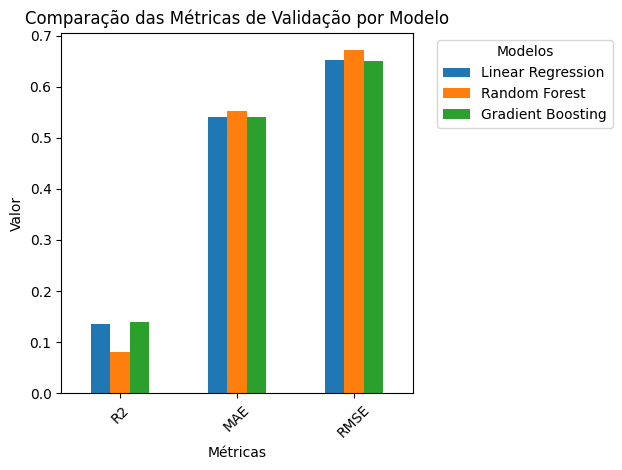

In [98]:
val_results_df = pd.DataFrame(val_results).round(4) #criar data frame pra mostrar resultados
print("\nResultados da Avaliação dos Modelos de validacao:")
print(val_results_df)
plt.figure(figsize=(12, 6)) #plotar os resultados
val_results_df.plot(kind='bar')
plt.title('Comparação das Métricas de Validação por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [99]:
#selecao do(s) melhor(es) modelo(s)

rmse_diff = {model: abs(train_results[model]['RMSE'] - val_results[model]['RMSE']) for model in models}
print('\nVerificação completa dos critérios:')
for model_name in models:
    print(f"\nModelo: {model_name}")
    rmse_ok = val_results[model_name]['RMSE'] < 0.651
    r2_ok = val_results[model_name]['R2'] > 0.35
    diff_ok = rmse_diff[model_name] < 0.15
    print(f"- RMSE < 0.65: {'sim' if rmse_ok else 'nao'} ({val_results[model_name]['RMSE']:.4f})")
    print(f"- R² > 0.35: {'sim' if r2_ok else 'nao'} ({val_results[model_name]['R2']:.4f})")
    print(f"- Diff RMSE < 0.15: {'sim' if diff_ok else 'nao'} ({rmse_diff[model_name]:.4f})")
    print(f"Todos critérios atendidos: {'sim' if (rmse_ok and r2_ok and diff_ok) else 'nao'}")


Verificação completa dos critérios:

Modelo: Linear Regression
- RMSE < 0.65: nao (0.6519)
- R² > 0.35: nao (0.1351)
- Diff RMSE < 0.15: sim (0.0095)
Todos critérios atendidos: nao

Modelo: Random Forest
- RMSE < 0.65: nao (0.6719)
- R² > 0.35: nao (0.0811)
- Diff RMSE < 0.15: nao (0.4214)
Todos critérios atendidos: nao

Modelo: Gradient Boosting
- RMSE < 0.65: sim (0.6500)
- R² > 0.35: nao (0.1400)
- Diff RMSE < 0.15: sim (0.0094)
Todos critérios atendidos: nao


**Modelo selecionado : Gradient Boosting**


2 : 4.420431455085516
3 : 3.7526999855204424
4 : 3.423534601638483
5 : 3.1940703780942576


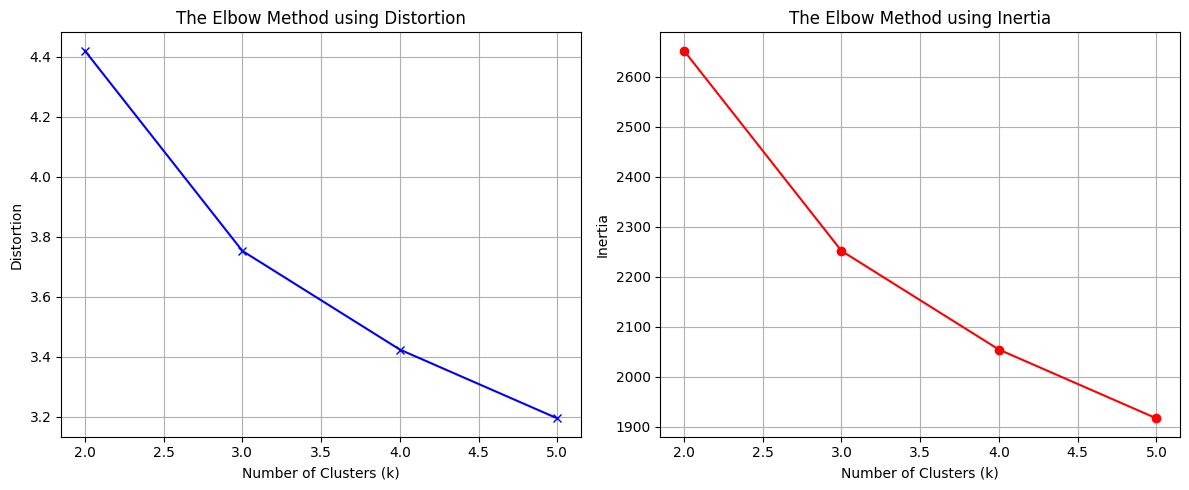

In [100]:
y_selected = models["Gradient Boosting"].predict(X_val_scaled)

# Aplicar PCA para reduzir a 2 dimensões para visualização
pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_val_scaled)

K = range(2, 6)
distortion = []
inertia = []
mapping_distortion = {}
mapping_inertia = {}

for k in K:  # Testando para valores de K ótimo
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X_val_scaled)
    
    distortion.append(sum(np.min(cdist(X_val_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_val_scaled.shape[0])
    inertia.append(kmeanModel.inertia_)
    
    mapping_distortion[k] = distortion[-1]
    mapping_inertia[k] = inertia[-1]
    
for key, val in mapping_distortion.items():
    print(f'{key} : {val}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, distortion, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(K, inertia, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.grid()

plt.tight_layout()
plt.show()


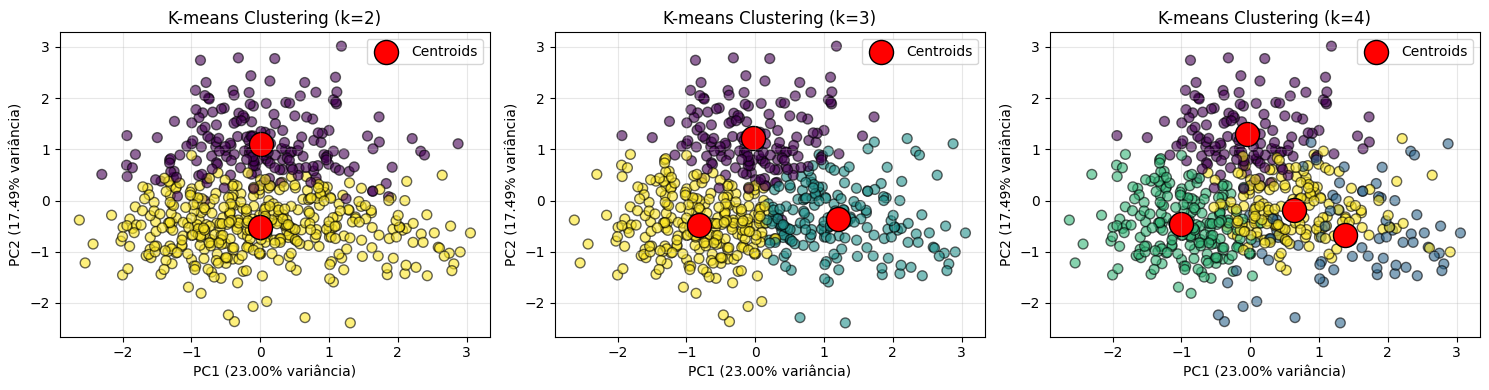

In [102]:
k_range = range(2, 5)

plt.figure(figsize=(15, 4))

for idx, k in enumerate(k_range, 1):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X_val_scaled)
    
    # Transformar centróides para o espaço PCA
    centers_pca = pca_viz.transform(kmeans.cluster_centers_)
    
    plt.subplot(1, 3, idx)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', marker='o', edgecolor='k', s=50, alpha=0.6)
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=300, c='red', label='Centroids', edgecolor='k', marker='o')
    plt.title(f'K-means Clustering (k={k})')
    plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} variância)')
    plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} variância)')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
